# 02.21 — Vanilla TabEBM (원본 SGLD) 샘플 시각화

논문 원본 `TabEBM().generate()` 로 생성한 synthetic samples 을
ensemble std heatmap 위에 plot. VP-SGLD 결과와 비교용.

## 0. Setup

In [1]:
%matplotlib inline
import os, json, time
os.chdir('/home/work/JooKyung/TabEBM')
import sys; sys.path.insert(0, 'experiments'); sys.path.insert(0, 'src')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tabebm.TabEBM import TabEBM
from viz_trajectory import precompute_class_viz_context
print('ready')

ready


## 1. 설정

In [2]:
# --- 대상 ensemble (heatmap 배경용) ---
ENSEMBLE_ROOT = Path('experiments/ebms/20260415_214026_Distance_EBM')  # ← 변경
assert (ENSEMBLE_ROOT / 'c0').exists()

# --- vanilla TabEBM 파라미터 (논문 기본값) ---
NUM_SAMPLES          = 500          # 생성할 synthetic 수 (class 당)
SGLD_STEPS           = 200          # 논문 기본 T=200
SGLD_STEP_SIZE       = 0.1          # 논문 기본 η=0.1
SGLD_NOISE_STD       = 0.01         # 논문 기본 σ=0.01
DISTANCE_NEG         = 5.0          # 논문 기본 α=5
STARTING_NOISE_STD   = 0.01         # 논문 기본
SEED                 = 42
GPU                  = 0
CLASSES              = [0, 1]

# --- heatmap 설정 ---
VIZ_HEATMAP_PAD = 3.0

# --- 출력 ---
OUT_DIR = ENSEMBLE_ROOT / 'comparisons' / 'vanilla_tabebm_viz'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'ENSEMBLE_ROOT: {ENSEMBLE_ROOT}')
print(f'OUT_DIR:       {OUT_DIR}')
print(f'TabEBM params: T={SGLD_STEPS}, η={SGLD_STEP_SIZE}, σ={SGLD_NOISE_STD}, '
       f'α={DISTANCE_NEG}, N={NUM_SAMPLES}')

ENSEMBLE_ROOT: experiments/ebms/20260415_214026_Distance_EBM
OUT_DIR:       experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz
TabEBM params: T=200, η=0.1, σ=0.01, α=5.0, N=500


## 2. Vanilla TabEBM 샘플 생성

`TabEBM().generate(X, y, ...)` — 논문 그대로의 plain SGLD.

In [3]:
# real 데이터 로드
data = np.load(ENSEMBLE_ROOT / 'c0' / 'class_data.npz')
X_all, y_all = data['X_all'], data['y_all']
print(f'X_all: {X_all.shape}, classes: {sorted(np.unique(y_all).tolist())}')

# vanilla TabEBM 생성
te = TabEBM(device=f'cuda:{GPU}')
t0 = time.time()
res = te.generate(
    X_all, y_all,
    num_samples=NUM_SAMPLES,
    sgld_steps=SGLD_STEPS,
    sgld_step_size=SGLD_STEP_SIZE,
    sgld_noise_std=SGLD_NOISE_STD,
    distance_negative_class=DISTANCE_NEG,
    starting_point_noise_std=STARTING_NOISE_STD,
    seed=SEED,
)
print(f'generate 완료 ({time.time()-t0:.1f}s)')

# class 별 synthetic 추출
vanilla_syn = {}
for c in CLASSES:
    key = f'class_{int(c)}'
    vanilla_syn[c] = res[key]
    print(f'  class {c}: {vanilla_syn[c].shape}')

X_all: (100, 9), classes: [0, 1]
generate 완료 (40.5s)
  class 0: (500, 9)
  class 1: (500, 9)


## 3. EBM heatmap + vanilla 샘플 시각화

배경: ensemble std heatmap (VP-SGLD 결과와 동일한 좌표계).
위에 real (cyan) + neg (red +) + **vanilla TabEBM synthetic (white dots)**.

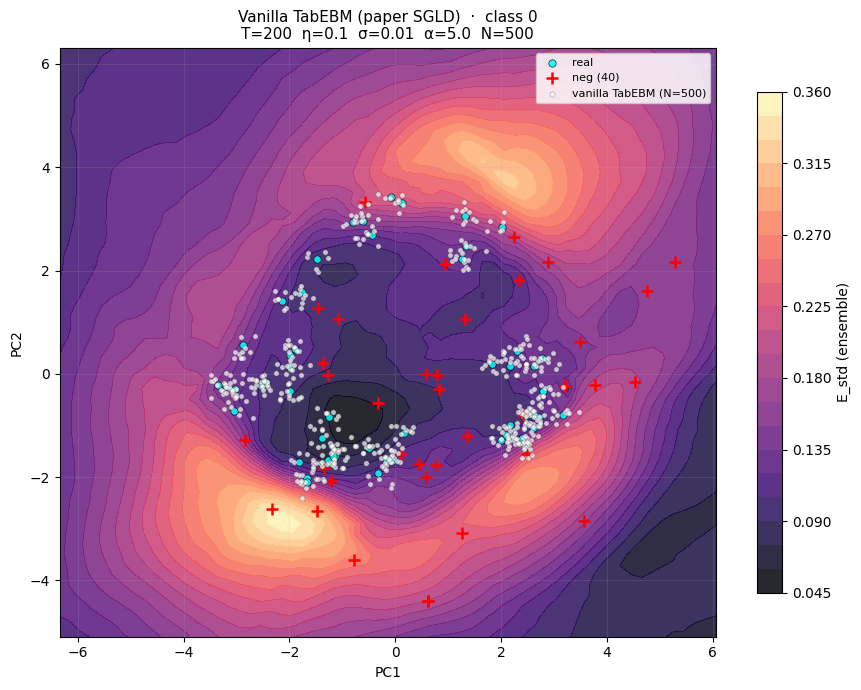

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz/vanilla_tabebm_c0.png


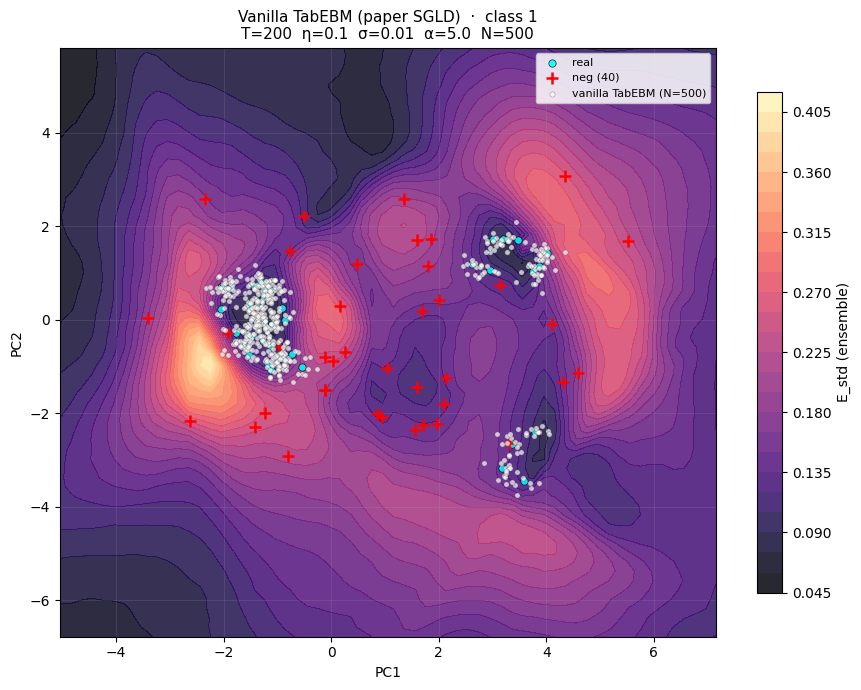

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz/vanilla_tabebm_c1.png


In [4]:
ctx = {}
for c in CLASSES:
    ctx[c] = precompute_class_viz_context(ENSEMBLE_ROOT / f'c{c}',
                                            pad=VIZ_HEATMAP_PAD, gpu=GPU)

for c in CLASSES:
    pca = ctx[c]['pca']
    Z_real, Z_neg, hm = ctx[c]['Z_real'], ctx[c]['Z_neg'], ctx[c]['hm']
    xlim, ylim = ctx[c]['xlim'], ctx[c]['ylim']

    Z_syn = pca.transform(vanilla_syn[c])

    fig, ax = plt.subplots(figsize=(9, 7))
    cs = ax.contourf(hm['ZZ1'], hm['ZZ2'], hm['std'], levels=24,
                      cmap='magma', alpha=0.85)
    fig.colorbar(cs, ax=ax, shrink=0.85, label='E_std (ensemble)')
    ax.scatter(Z_real[:,0], Z_real[:,1], s=28, c='cyan',
                edgecolors='black', linewidths=0.5, label='real', alpha=0.85, zorder=4)
    if len(Z_neg):
        ax.scatter(Z_neg[:,0], Z_neg[:,1], s=80, c='red', marker='+',
                    linewidths=1.8, label=f'neg ({len(Z_neg)})', zorder=5)
    ax.scatter(Z_syn[:,0], Z_syn[:,1], s=14, c='white',
                edgecolors='0.3', linewidths=0.3,
                label=f'vanilla TabEBM (N={len(Z_syn)})', alpha=0.7, zorder=6)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Vanilla TabEBM (paper SGLD)  ·  class {c}\n'
                  f'T={SGLD_STEPS}  η={SGLD_STEP_SIZE}  σ={SGLD_NOISE_STD}  '
                  f'α={DISTANCE_NEG}  N={NUM_SAMPLES}', fontsize=11)
    ax.legend(fontsize=8, loc='upper right', framealpha=0.85)
    ax.grid(alpha=0.15)
    plt.tight_layout()
    p = OUT_DIR / f'vanilla_tabebm_c{c}.png'
    fig.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  saved: {p}')

## 4. VP-SGLD 와 나란히 비교 (선택)

특정 VP-SGLD config 의 final samples 과 vanilla 를 같은 heatmap 위에.

In [5]:
# --- VP-SGLD 결과 경로 (있으면 비교, 없으면 skip) ---
VP_NPZ_FOLDER = None   # 예: ENSEMBLE_ROOT / 'comparisons' / 'sessions' / '<ts>' / 'sweeps' / 'beta__100.0'
# VP_NPZ_FOLDER = ENSEMBLE_ROOT / 'comparisons' / 'sessions' / '20260416_213939_all_axes_baseline' / 'sweeps' / 'beta__100.0'

if VP_NPZ_FOLDER is not None:
    VP_NPZ_FOLDER = Path(VP_NPZ_FOLDER)
    vp_cfg = json.loads((VP_NPZ_FOLDER / 'run_config.json').read_text())['cfg']
    vp_label = VP_NPZ_FOLDER.name

    for c in CLASSES:
        npz = VP_NPZ_FOLDER / f'diag_raw_c{c}.npz'
        if not npz.exists():
            print(f'  [skip] {vp_label} c{c}'); continue
        d = np.load(npz, allow_pickle=True)
        vp_final = d['trajectory'][-1]   # (N, d)

        pca = ctx[c]['pca']
        Z_real, Z_neg, hm = ctx[c]['Z_real'], ctx[c]['Z_neg'], ctx[c]['hm']
        xlim, ylim = ctx[c]['xlim'], ctx[c]['ylim']
        Z_vanilla = pca.transform(vanilla_syn[c])
        Z_vp = pca.transform(vp_final)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
        for ax, Z_pts, title, color in [
            (axes[0], Z_vanilla, f'Vanilla TabEBM\nT={SGLD_STEPS} η={SGLD_STEP_SIZE} σ={SGLD_NOISE_STD}', 'white'),
            (axes[1], Z_vp, f'VP-SGLD ({vp_label})\nβ={vp_cfg["beta"]} η={vp_cfg["eta"]} τ={vp_cfg["tau"]}', 'lime'),
        ]:
            ax.contourf(hm['ZZ1'], hm['ZZ2'], hm['std'], levels=24,
                         cmap='magma', alpha=0.85)
            ax.scatter(Z_real[:,0], Z_real[:,1], s=28, c='cyan',
                        edgecolors='black', linewidths=0.5, label='real', alpha=0.85, zorder=4)
            if len(Z_neg):
                ax.scatter(Z_neg[:,0], Z_neg[:,1], s=60, c='red', marker='+',
                            linewidths=1.5, label='neg', zorder=5)
            ax.scatter(Z_pts[:,0], Z_pts[:,1], s=14, c=color,
                        edgecolors='0.3', linewidths=0.3,
                        label=f'synthetic (N={len(Z_pts)})', alpha=0.7, zorder=6)
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_xlabel('PC1'); ax.set_title(title, fontsize=10)
            ax.legend(fontsize=7, loc='upper right')
            ax.grid(alpha=0.15)
        axes[0].set_ylabel('PC2')
        fig.suptitle(f'Vanilla vs VP-SGLD  ·  class {c}', fontsize=12, y=1.01)
        plt.tight_layout()
        p = OUT_DIR / f'compare_vanilla_vs_vp_c{c}.png'
        fig.savefig(p, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  saved: {p}')
else:
    print('VP_NPZ_FOLDER = None → 비교 skip. 위 변수에 VP-SGLD sweep 폴더 경로 넣으면 비교.')

VP_NPZ_FOLDER = None → 비교 skip. 위 변수에 VP-SGLD sweep 폴더 경로 넣으면 비교.


## 5. Vanilla TabEBM 파라미터 sweep (선택)

논문 기본값 외에 다른 SGLD 파라미터로도 돌려보고 싶을 때.

T=50: 9.7s


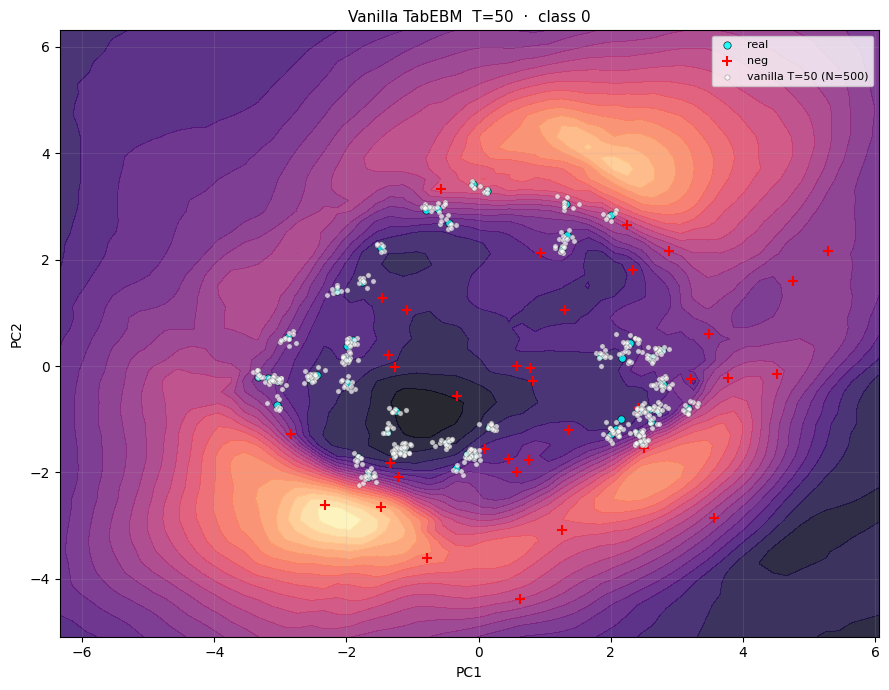

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz/vanilla_T50_c0.png


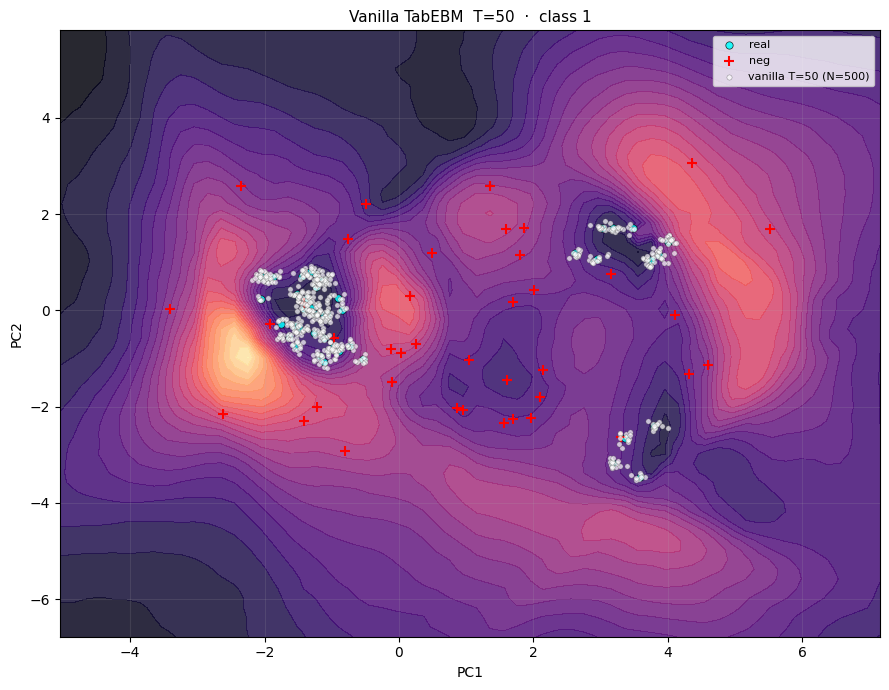

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz/vanilla_T50_c1.png
T=200: 40.0s


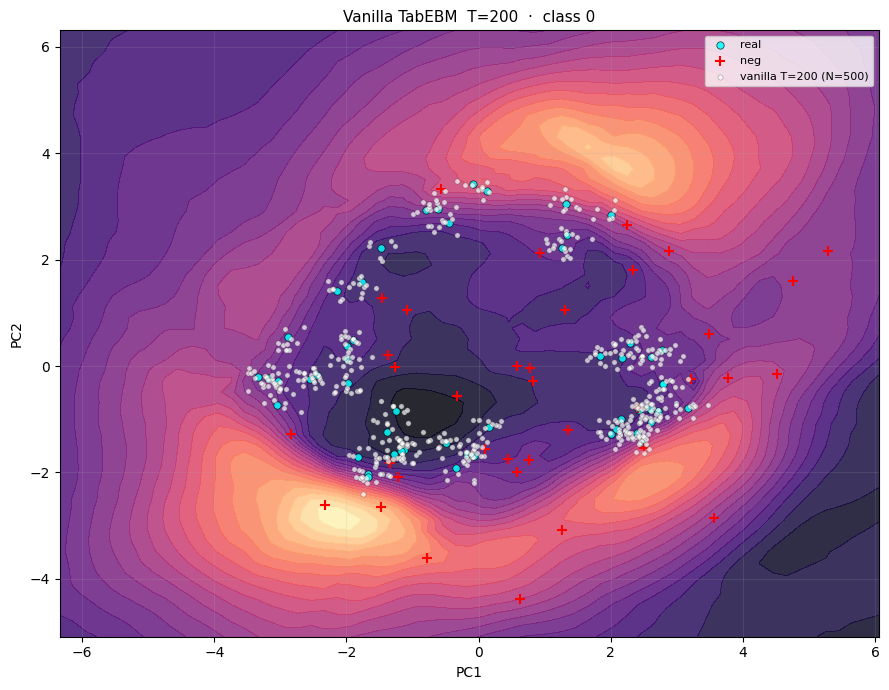

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz/vanilla_T200_c0.png


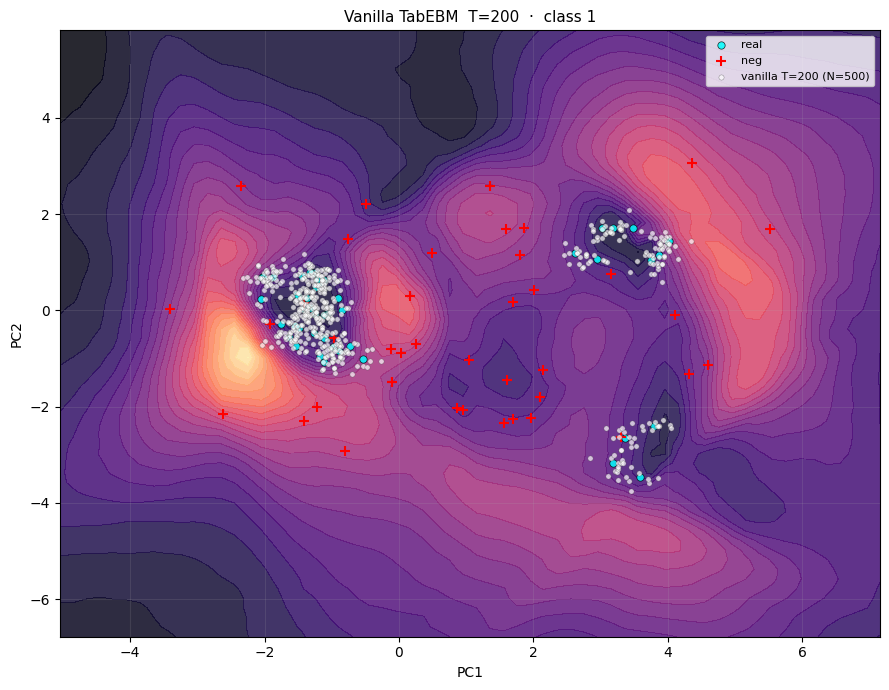

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz/vanilla_T200_c1.png
T=500: 96.6s


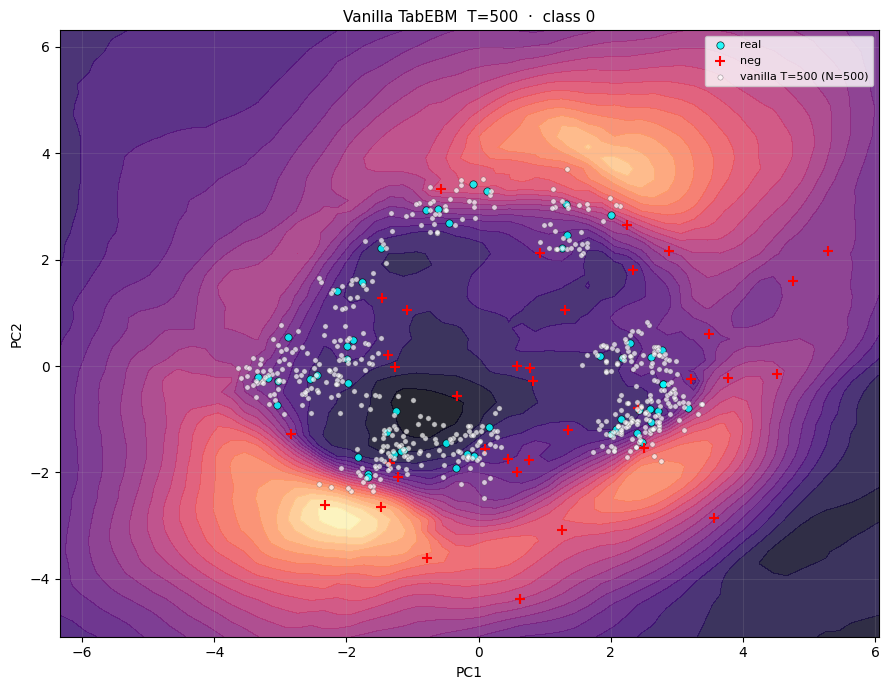

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz/vanilla_T500_c0.png


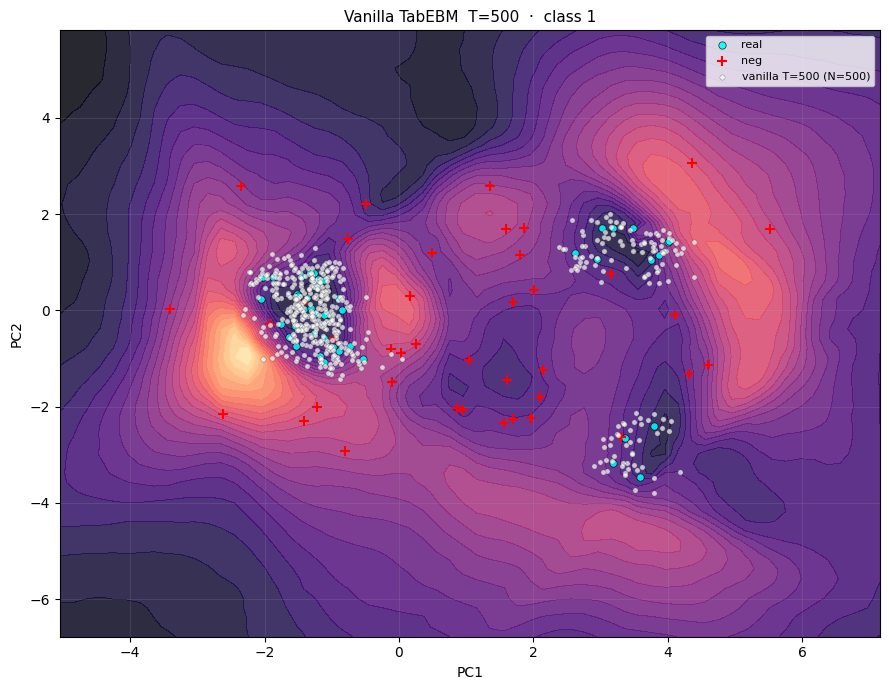

  saved: experiments/ebms/20260415_214026_Distance_EBM/comparisons/vanilla_tabebm_viz/vanilla_T500_c1.png


In [6]:
# T sweep — 논문 기본 T=200 외에 다른 step 수
T_SWEEP = [50, 200, 500]
# T_SWEEP = None   # ← None 이면 skip

if T_SWEEP is not None:
    for T in T_SWEEP:
        te_s = TabEBM(device=f'cuda:{GPU}')
        t0 = time.time()
        res_s = te_s.generate(
            X_all, y_all, num_samples=NUM_SAMPLES,
            sgld_steps=T, sgld_step_size=SGLD_STEP_SIZE,
            sgld_noise_std=SGLD_NOISE_STD,
            distance_negative_class=DISTANCE_NEG,
            starting_point_noise_std=STARTING_NOISE_STD,
            seed=SEED,
        )
        print(f'T={T}: {time.time()-t0:.1f}s')

        for c in CLASSES:
            pca = ctx[c]['pca']
            Z_real, Z_neg, hm = ctx[c]['Z_real'], ctx[c]['Z_neg'], ctx[c]['hm']
            xlim, ylim = ctx[c]['xlim'], ctx[c]['ylim']
            Z_syn = pca.transform(res_s[f'class_{int(c)}'])

            fig, ax = plt.subplots(figsize=(9, 7))
            ax.contourf(hm['ZZ1'], hm['ZZ2'], hm['std'], levels=24,
                         cmap='magma', alpha=0.85)
            ax.scatter(Z_real[:,0], Z_real[:,1], s=28, c='cyan',
                        edgecolors='black', linewidths=0.5, label='real', alpha=0.85, zorder=4)
            if len(Z_neg):
                ax.scatter(Z_neg[:,0], Z_neg[:,1], s=60, c='red', marker='+',
                            linewidths=1.5, label='neg', zorder=5)
            ax.scatter(Z_syn[:,0], Z_syn[:,1], s=14, c='white',
                        edgecolors='0.3', linewidths=0.3,
                        label=f'vanilla T={T} (N={len(Z_syn)})', alpha=0.7, zorder=6)
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
            ax.set_title(f'Vanilla TabEBM  T={T}  ·  class {c}', fontsize=11)
            ax.legend(fontsize=8, loc='upper right')
            ax.grid(alpha=0.15)
            plt.tight_layout()
            p = OUT_DIR / f'vanilla_T{T}_c{c}.png'
            fig.savefig(p, dpi=150, bbox_inches='tight')
            plt.show()
            print(f'  saved: {p}')
else:
    print('T_SWEEP = None → skip')